In [ ]:
import os
import random
import subprocess
import time
from collections import namedtuple
from collections.abc import Iterable
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.metrics import r2_score
from torch import Tensor
from torch_geometric.data import Data
from tqdm import tqdm

import network
from graph_utils import (
    LJInteractionParams,
    get_correct_edge_attr,
    get_correct_edge_vec,
    prepare_traj,
    to_directed_graph,
)
from itpo_weights import DatasetType
from lammps_scripts import CompressionSimulation, LJSimulation, TemperatureRange
from network import Atom, Bond, Header, Network
from pressure import (
    compute_per_particle_forces,
    compute_stress_curve,
    compute_stress_pressure,
)
from torch_simulator_wLJ_64 import DifferentiableCompression64
from utils import (
    calc_p_ratio_box_tensor,
    draw_graph,
    load_and_split_dataset,
    to_f32,
    to_f64,
    visualize_graphs,
    visualize_nu_disribution,
)

### Load data

In [2]:
# poisson_buckets = [
#     {"max": 0.1, "count": 10},                # P < 0.1
#     {"min": 0.1, "max": 0.2, "count": 10},    # 0.1 <= P < 0.2
#     {"min": 0.2, "count": 30}                 # P >= 0.2
# ]

poisson_buckets = [
    {"min": 0.0, "max": 1.0, "count": 30},    # Full P range
]

dataset_type = DatasetType.LJNoisy

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data/data_registry.csv",
    # registry_path="./data/new_node_optimized/data_registry.csv",
    registry_path="./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.9, 0.05, 0.05),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 300
print(f"Loading data with max simulation length of {max_sim_len}...")
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
default_params = LJInteractionParams(epsilon=0.01, sigma=1.0, cutoff=1.122)
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, default_params if dataset_type is DatasetType.LJNoisy else None, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


Loading data with max simulation length of 300...


test  data: 100%|██████████| 2/2 [00:00<00:00, 11.95it/s]



Preparing data...


test  data: 100%|██████████| 2/2 [00:00<00:00,  2.58it/s]


Train data: 27 sims.
Val data:   1 sims.
Test data:  2 sims.


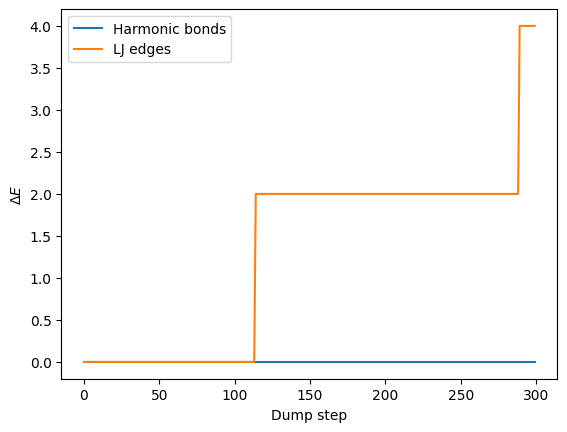

In [5]:
random_sim = random.sample(data['train'], k=1)[0]

num_edges = torch.Tensor([g.edge_attr.shape[0] for g in random_sim])
num_harm_edges = torch.Tensor([g.edge_attr[g.edge_attr[:, 0].bool()].shape[0] for g in random_sim])
num_lj_edges = torch.Tensor([g.edge_attr[g.edge_attr[:, 1].bool()].shape[0] for g in random_sim])

plt.plot(num_harm_edges - num_harm_edges[0], label="Harmonic bonds")
plt.plot(num_lj_edges - num_lj_edges[0], label="LJ edges")
plt.ylabel(r"$\Delta E$")
plt.xlabel("Dump step")
plt.legend()
plt.show()

Num nodes:          torch.Size([155, 2])
Num total edges:    torch.Size([1538, 7])
Num harmonic edges: torch.Size([634, 7])
Num LJ edges:       torch.Size([904, 7])
torch.Size([1, 1538])
torch.Size([1, 1538])


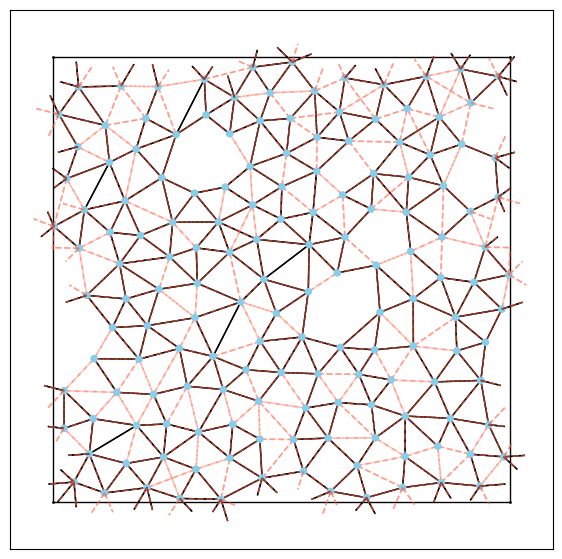

In [7]:
graph = data["train"][0][0]

is_harmonic = graph.edge_attr[:, 0].bool()
is_lj = graph.edge_attr[:, 1].bool()
print(f"Num nodes:          {graph.x.shape}")
print(f"Num total edges:    {graph.edge_attr.shape}")
print(f"Num harmonic edges: {graph.edge_attr[is_harmonic].shape}")
print(f"Num LJ edges:       {graph.edge_attr[is_lj].shape}")

edges = graph.edge_attr
harmonic_edges = edges[edges[:, 0].bool()]
lj_edges = edges[edges[:, 1].bool()]

old_edges = graph.edge_attr.clone()

new_edges = get_correct_edge_attr(graph, recompute_stiff=False, lj_params=LJInteractionParams(), panic_at_nontensor_box=True)
if isinstance(new_edges, Tensor):
    print(new_edges[new_edges[:, 0].bool()].shape)
    print(new_edges[new_edges[:, 1].bool()].shape)
else:
    new_edge_attr, new_edge_index = new_edges
    print(new_edge_attr[new_edge_attr[:, 0].bool()].shape)
    print(new_edge_attr[new_edge_attr[:, 1].bool()].shape)

draw_graph(data["train"][0][0], periodic_edges=True, box=True)


### Generate a fresh simulation

In [ ]:
LJParameters = namedtuple(
    "LJParameters",
    ["n_atoms", "atom_sizes", "box_dim", "t_start", "t_end", "n_steps"],
)

CompressionParameters = namedtuple(
    "CompressionParameters",
    ["strain", "strain_rate", "step_size", "t_start", "t_end", "dump_frequency"],
)


def run_lammps_calc(calculation_directory: str, input_file: str = "lammps.in"):
    """
    A helper function which runs the external lammps code.
    """
    input_file_path = os.path.join(calculation_directory, input_file)
    command = f"lmp -in {input_file_path}".split()

    os.chdir(calculation_directory)
    os.environ["OMP_NUM_THREADS"] = str(1)
    subprocess.run(command, stdout=subprocess.DEVNULL, check=False)


def assemble_data(
    atoms: list[network.Atom],
    bonds: list[network.Bond],
    box: network.Box,
    node_features: str = "coord",
) -> Data:
    """Optimized helper function which assembles the PyTorch_Geometric `Data` object.
    
    Parameters
    ----------
    `atoms` : list
        list of `network.Atom` objects transformed into nodes
    `bonds` : list
        list of `network.Bond` objects transformed into edges
    `node_features` : str, optional
        which node features to include, by default "coord"
    
    Returns
    -------
    Data
        PyTorch_Geometric `Data` object
    """
    n_atoms = len(atoms)

    # Vectorized atom ID extraction and mapping
    atom_ids_np = np.array([atom.atom_id for atom in atoms], dtype=np.int64)
    atom_ids = torch.from_numpy(atom_ids_np)
    
    # Create efficient lookup using numpy
    max_id = atom_ids_np.max() + 1
    id_to_index = np.full(max_id, -1, dtype=np.int64)
    id_to_index[atom_ids_np] = np.arange(n_atoms)
    
    # Vectorized edge extraction
    edges_np = np.array([(bond.atom1.atom_id, bond.atom2.atom_id) for bond in bonds], dtype=np.int64)
    edges_with_indices = np.column_stack([
        id_to_index[edges_np[:, 0]],
        id_to_index[edges_np[:, 1]]
    ])
    edge_index = torch.from_numpy(edges_with_indices.T)
    
    # Vectorized edge attributes - build numpy arrays first
    edge_vectors_np = np.array([
        [bond.atom1.x - bond.atom2.x, bond.atom1.y - bond.atom2.y] 
        for bond in bonds
    ], dtype=np.float64)
    
    edge_lengths_np = np.array([bond.length for bond in bonds], dtype=np.float64)
    edge_coeffs_np = np.array([bond.bond_coefficient for bond in bonds], dtype=np.float64)
    
    # Convert to tensors once
    edge_vectors = torch.from_numpy(edge_vectors_np)
    edge_lengths = torch.from_numpy(edge_lengths_np).unsqueeze(1)
    edge_coeffs = torch.from_numpy(edge_coeffs_np).unsqueeze(1)
    
    # Concatenate efficiently
    edge_attr = torch.cat([edge_vectors, edge_lengths, edge_coeffs], dim=1)
    
    # Vectorized node features
    match node_features:
        case "dummy":
            node_features_tensor = torch.zeros((n_atoms, 1), dtype=torch.float32)
        case "vel":
            try:
                node_features_np = np.array([[atom.vx, atom.vy] for atom in atoms], dtype=np.float64)
                node_features_tensor = torch.from_numpy(node_features_np)
            except AttributeError:
                raise Exception("Atoms don't have velocity info")  # noqa: TRY002
        case "force":
            try:
                node_features_np = np.array([[atom.fx, atom.fy] for atom in atoms], dtype=np.float64)
                node_features_tensor = torch.from_numpy(node_features_np)
            except AttributeError:
                raise Exception("Atoms don't have forces info")  # noqa: TRY002
        case "coord":
            node_features_np = np.array([[atom.x, atom.y] for atom in atoms], dtype=np.float64)
            node_features_tensor = torch.from_numpy(node_features_np)
        case "full":
            node_features_np = np.array([
                [atom.x, atom.y, atom.vx, atom.vy, atom.fx, atom.fy] 
                for atom in atoms
            ], dtype=np.float64)
            node_features_tensor = torch.from_numpy(node_features_np)
        case _:
            raise Exception(f"{node_features} not recognized as feature!")  # noqa: TRY002
    
    # Create temporary Data object
    tmp = Data(
        x=node_features_tensor, 
        edge_index=edge_index, 
        edge_attr=edge_attr, 
        box=box, 
        atom_ids=atom_ids
    )
    
    # Get corrected edge vectors
    correct_edge_vectors = get_correct_edge_vec(tmp)
    
    # Update edge attributes efficiently
    updated_edge_attr = torch.cat([correct_edge_vectors, edge_lengths, edge_coeffs], dim=1)
    
    return Data(
        x=node_features_tensor,
        edge_index=edge_index,
        edge_attr=updated_edge_attr,
        box=box,
    )


def parse_dump(
    dump_filepath: str,
    original_network: network.Network,
    node_features: str = "full",
    skip: int = 1,
) -> list[Data]:
    """Optimized version that parses a lammps dump file using vectorization.

    Parameters
    ----------
    `dump_filepath` : str
        Path to the lammps trajectory files
    `original_network` : network.Network
        simulated network to get the accurate information about periodic bonds
    `node_features` : str, optional
        node features to include into Data object, by default "full".
    `skip` : int, optional
        load each n-th step starting from the first, by default 1 (skip none)

    Returns
    -------
    list[Data]
        list of pytorch_geometric Data objects
    """
    with open(dump_filepath, "r", encoding="utf8") as f:
        content = f.readlines()

    # Find all timesteps
    timesteps = [i for i, line in enumerate(content) if "ITEM: TIMESTEP" in line]

    # Pre-compute lookups
    atom_diameter_map = {atom.atom_id: atom.diameter for atom in original_network.atoms}
    original_edge_index = np.array([
        (bond.atom1.atom_id, bond.atom2.atom_id) for bond in original_network.bonds
    ])
    bond_stiffness_map = {
        (bond.atom1.atom_id, bond.atom2.atom_id): bond.bond_coefficient
        for bond in original_network.bonds
    }

    data_list = []
    for i in range(0, len(timesteps) - 1, skip):
        timestep_data = content[timesteps[i] : timesteps[i + 1]]

        # Parse box info
        box_data = [line.split() for line in timestep_data[5:8]]
        x1, x2 = float(box_data[0][0]), float(box_data[0][1])
        y1, y2 = float(box_data[1][0]), float(box_data[1][1])
        z1, z2 = float(box_data[2][0]), float(box_data[2][1])
        box = network.Box(x1, x2, y1, y2, z1, z2)
        box_x = x2 - x1
        box_y = y2 - y1

        # Vectorized atom parsing
        atom_lines = [line.split() for line in timestep_data[9:]]
        atom_data = np.array(atom_lines, dtype=float)
        
        atom_ids = atom_data[:, 0].astype(int)
        positions = atom_data[:, 1:4]  # x, y, z
        velocities = atom_data[:, 4:7]  # vx, vy, vz

        # Create atoms efficiently
        new_atoms = []
        atom_id_to_idx = {}
        for idx, atom_id in enumerate(atom_ids):
            atom = network.Atom(
                atom_id=atom_id,
                atom_diameter=atom_diameter_map[atom_id],
                x=positions[idx, 0],
                y=positions[idx, 1],
                z=positions[idx, 2],
            )
            try:
                atom.vx = velocities[idx, 0]
                atom.vy = velocities[idx, 1]
                atom.vz = velocities[idx, 2]
            except Exception:  # noqa: BLE001, S110
                pass # silently eating the exceptions because we don't care if there are velocities
            new_atoms.append(atom)
            atom_id_to_idx[atom_id] = idx

        # Vectorized bond distance calculation
        atom_map = {atom.atom_id: atom for atom in new_atoms}
        
        # Get positions for all bonds
        idx1 = np.array([atom_id_to_idx[edge[0]] for edge in original_edge_index])
        idx2 = np.array([atom_id_to_idx[edge[1]] for edge in original_edge_index])
        
        pos1 = positions[idx1, :2]  # Only x, y for 2D
        pos2 = positions[idx2, :2]
        
        # Vectorized periodic distance calculation
        delta = pos2 - pos1
        
        # Apply periodic boundary conditions
        delta[:, 0] = np.where(np.abs(delta[:, 0]) > box_x / 2,
                               delta[:, 0] - np.sign(delta[:, 0]) * box_x,
                               delta[:, 0])
        delta[:, 1] = np.where(np.abs(delta[:, 1]) > box_y / 2,
                               delta[:, 1] - np.sign(delta[:, 1]) * box_y,
                               delta[:, 1])
        
        # Calculate distances
        distances = np.linalg.norm(delta, axis=1)
        
        # Create bonds
        new_bonds = []
        for bond_idx, (id1, id2) in enumerate(original_edge_index):
            new_bond = network.Bond(atom_map[id1], atom_map[id2])
            new_bond.length = distances[bond_idx]
            new_bond.bond_coefficient = bond_stiffness_map[(id1, id2)]
            new_bonds.append(new_bond)

        data_list.append(assemble_data(new_atoms, new_bonds, box, node_features=node_features))

    return data_list


def network_from_data(data_object: Data) -> network.Network:
    """Transforms PyTorch Data object into Network object.

    Parameters
    ----------
    `data_object` : Data
        PyTorch Data object containing the graph
    `template` : network.Network
        original network compressed with lammps from which data object was made

    Returns
    -------
    network.Network
        updated network
    """
    
    # Make input graph directed
    data_object = to_directed_graph(data_object)
    
    # Create atoms 
    atoms = []
    for index, node in enumerate(data_object.x):
        atom_id = index + 1
        x = float(node[0])
        y = float(node[1])
        atoms.append(Atom(atom_id=atom_id, atom_diameter=0.0, x=x, y=y, z=0.0))
    
    # Create bonds
    bonds=[]
    for index, ((source_id, target_id), (ux, uy, length, k)) in enumerate(zip(data_object.edge_index.T, data_object.edge_attr)):
        atom1 = atoms[int(source_id)]
        atom1.n_bonds += 1
        atom2 = atoms[int(target_id)]
        atom2.n_bonds += 1
        atom2.bonded.append(atom1.atom_id)
        atom1.bonded.append(atom2.atom_id)
        bond_coefficient = float(k)
        length = float(length)
        
        bond = Bond(atom1, atom2)
        bond.bond_coefficient = bond_coefficient
        bond.length = length
        
        bonds.append(bond)

    # Add box
    box = data_object.box

    # Add header
    header = Header(
        atoms,
        bonds,
        box,
    )

    return Network(atoms, bonds, box, header, masses={1: 1000000.0})


def gen_new_prepared_sim(lj_params: LJParameters, comp_params: CompressionParameters, out_dir: str) -> list[Data]:
    lj_sim = LJSimulation(
        n_atoms=lj_params.n_atoms,
        atom_sizes=lj_params.atom_sizes,
        box_dim=lj_params.box_dim,
        temperature_range=TemperatureRange(lj_params.t_start, lj_params.t_end, 10.0),
        n_steps=lj_params.n_steps,
    )
    lj_sim.write_to_file(out_dir)
    run_lammps_calc(out_dir, input_file="lammps.in")

    # Convert to Network Object
    lammps_coord_file = os.path.join(out_dir, "coord.dat")

    local_network = network.Network.from_atoms(
        input_file=lammps_coord_file,
        periodic=True,
        include_default_masses=1e6,
        include_angles=True,
        include_dihedrals=False,
        zero_z=True,
    )

    # Save initial network state
    network_filepath = os.path.join(out_dir, "network.lmp")
    local_network.write_to_file(network_filepath)

    # Run compression
    comp_sim = CompressionSimulation(
        dt=0.01,
        strain=comp_params.strain,
        strain_rate=comp_params.strain_rate,
        desired_step_size=comp_params.step_size,
        box_size=local_network.box.x,
        network_filename="network.lmp",
        temperature_range=TemperatureRange(comp_params.t_start, comp_params.t_end, 10.0),
    )
    if comp_params.dump_frequency is not None:
        comp_sim.dump_frequency = comp_params.dump_frequency
    comp_sim.write_to_file(out_dir)
    run_lammps_calc(out_dir, input_file="in.deformation")

    # Parse compression and check P
    sim = parse_dump(os.path.join(out_dir, "dump.lammpstrj"), local_network, node_features="coord")
    prepared_sim = prepare_traj(sim)
    return prepared_sim


def recompress_existing_sim(starting_graph: Data, comp_params: CompressionParameters, out_dir: str) -> list[Data]:

    # create local out dir
    if not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)

    # Save initial network state
    local_network = network_from_data(starting_graph)
    # local_network.set_angle_coeff(0.00)
    network_filepath = os.path.join(out_dir, "network.lmp")
    local_network.write_to_file(network_filepath)

    # Run compression
    comp_sim = CompressionSimulation(
        dt=0.01,
        strain=comp_params.strain,
        strain_rate=comp_params.strain_rate,
        desired_step_size=comp_params.step_size,
        box_size=local_network.box.x,
        network_filename="network.lmp",
        temperature_range=TemperatureRange(comp_params.t_start, comp_params.t_end, 10.0),
    )
    if comp_params.dump_frequency is not None:
        comp_sim.dump_frequency = comp_params.dump_frequency
    comp_sim.write_to_file(out_dir)
    run_lammps_calc(out_dir, input_file="in.deformation")

    # Parse compression and check P
    prepared_sim = parse_dump(os.path.join(out_dir, "dump.lammpstrj"), local_network, node_features="coord")
    prepared_sim = prepare_traj(prepared_sim)
    # prepared_sim = [add_box_tensor(g, dtype=torch.float32) for g in prepared_sim]
    return prepared_sim


os.chdir("/home/sergey/work/gnn/GNNInverseDesign")

starting_graphs = [data["train"][i][0] for i in range(10)]

lj_params = LJParameters(
    n_atoms=150,
    atom_sizes=[1.0, 1.2, 1.4, 1.6],
    box_dim=[-60, 60, -60, 60, -0.1, 0.1],
    t_start=0.005,
    t_end=0.001,
    n_steps=10_000,
)

comp_params = CompressionParameters(
    strain=0.01,
    strain_rate=1e-5,
    step_size=0.001,
    t_start=1e-7,
    t_end=1e-7,
    dump_frequency=200,
)

out_dir = os.path.abspath("generated_network")
os.makedirs(out_dir, exist_ok=True)

# recomp_sims = []
# for idx, graph in enumerate(starting_graphs):
#     local_out_dir = os.path.join(out_dir, str(idx+1))
#     prepared_sim = recompress_existing_sim(graph, comp_params, local_out_dir)
#     recomp_sims.append(prepared_sim)
#     print(f"Length of the parsed sim: {len(prepared_sim)}")
#     p_ratio = calc_p_ratio_box_tensor(prepared_sim)
#     print(f"P ratio: {p_ratio:.3f}")

#     # save as torch pt file
#     save_path = os.path.join(local_out_dir, "sim.pt")
#     torch.save(prepared_sim, save_path)

recomp_sims = []
for idx, graph in enumerate(starting_graphs):
    local_out_dir = os.path.join(out_dir, str(idx+1))
    sim_path = os.path.join(local_out_dir, "sim.pt")

    prepared_sim = torch.load(sim_path, weights_only=False)
    recomp_sims.append(prepared_sim)

    print(f"Length of the parsed sim: {len(prepared_sim)}")
    p_ratio = calc_p_ratio_box_tensor(prepared_sim)
    print(f"P ratio: {p_ratio:.3f}")

draw_graph(prepared_sim[0])
os.chdir("/home/sergey/work/gnn/GNNInverseDesign")

data = {
    "train": recomp_sims,
    "val": [],
    "test": [],
}

visualize_nu_disribution(data)

### Simple test & box evolution

In [26]:
steps = 3_000
device = "cpu"
results = {
    "position_mse": [],
    "gt_box_change": [],
    "gt_box_p": [],
    "custom_box_p": [],
    "custom_box_change": [],
    "stress": [],
    "strain": [],
}

test_data = []
for v in data.values():
    test_data.extend(v)

# sims = random.sample(test_data, k=20)
sims = test_data[:10]

for sim in tqdm(sims):
    simulator: DifferentiableCompression64 = DifferentiableCompression64(
        num_particles=sim[0].num_nodes,
        mass=1.0e6,
        dt=0.01,
        damp=10.0,
        ptemp=1e-4,
        pdamp=1000,
        target_p=0.0,
        srate=1e-5,
        temp_langevin=1e-7,
        inertia_prefactor=1.0,
        lj_params=default_params if dataset_type is DatasetType.LJNoisy else None,
        factor_two=True,
    )

    strain = (sim[0].box.x - sim[-1].box.x) / sim[0].box.x
    assumed_rollout_length = int(strain / 1e-5 / 0.01)
    dump_period = int(assumed_rollout_length / len(sim)) + 1
    data_step0 = sim[0].to(device)
    data_step0 = to_f64(data_step0)
    
    # determine r0
    if data_step0.edge_attr.shape[1] == 4:
        r0 = data_step0.edge_attr[:, 2]
    elif data_step0.edge_attr.shape[1] == 7:
        harmonic_bond_edges = data_step0.edge_attr[data_step0.edge_attr[:, 0] == 1]
        r0 = harmonic_bond_edges[:, 4]
    else:
         raise ValueError(f"Unexpected edge_attr dimension: {data_step0.edge_attr.shape[1]}")

    simulator_rollout, conditions = simulator.run_simulator(
        initial_data=data_step0,
        steps=steps,
        r0=r0,
        debug=False,
        device=device,
    )
    # simulator_rollout, conditions = simulator.run_simulator_to_strain(
    #     initial_data=to_f64(data_step0),
    #     target_strain=0.0001,
    #     r0=r0,
    #     debug=False,
    #     device=device,
    # )

    # Coarse grain to match GT Lammps 
    simulator_rollout = [step for i, step in enumerate(simulator_rollout) if i % dump_period == 0]
    target_idx = len(simulator_rollout) - 1

    # Collect results
    gt_box_change = [graph.box_tensor.cpu().detach() for graph in sim[:target_idx]]
    results["gt_box_change"].append(gt_box_change)

    custom_box_change = [graph.box_tensor.cpu().detach() for graph in simulator_rollout[:target_idx]]
    results["custom_box_change"].append(custom_box_change)

    mse = torch.nn.functional.mse_loss(simulator_rollout[-1].x, sim[target_idx].x)
    results["position_mse"].append(mse.item())

    gt_box_p = calc_p_ratio_box_tensor(sim, target_idx)
    results["gt_box_p"].append(gt_box_p.item())

    custom_box_p = calc_p_ratio_box_tensor(simulator_rollout, target_idx)
    results["custom_box_p"].append(custom_box_p.item())

    stress_curve = compute_stress_curve(simulator_rollout, lj_cutoff=1.122, sample_stride=1)
    results["stress"].append(stress_curve.detach())

    final_strain = (sim[0].box_tensor[0] - sim[target_idx].box_tensor[0]) / sim[0].box_tensor[0]
    results["strain"].append(final_strain.item())


100%|██████████| 10/10 [00:39<00:00,  3.92s/it]


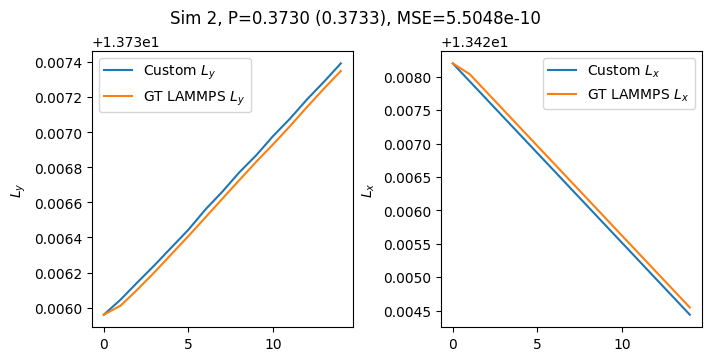

In [35]:
rand_i = random.randint(0, len(results["custom_box_change"])-1)

fig, ax = plt.subplots(1, 2, layout="constrained", sharex=True, figsize=(7, 3.5))

ax[0].plot([box[1] for box in results["custom_box_change"][rand_i]], label="Custom $L_y$")
ax[0].plot([box[1] for box in results["gt_box_change"][rand_i]], label="GT LAMMPS $L_y$")
ax[0].legend()
ax[0].set_ylabel("$L_y$")

ax[1].plot([box[0] for box in results["custom_box_change"][rand_i]], label="Custom $L_x$")
ax[1].plot([box[0] for box in results["gt_box_change"][rand_i]], label="GT LAMMPS $L_x$")
ax[1].legend()
ax[1].set_ylabel("$L_x$")

pred_p = results['custom_box_p'][rand_i]
gt_p = results['gt_box_p'][rand_i]
mse = results['position_mse'][rand_i]
plt.suptitle(f"Sim {rand_i}, P={pred_p:.4f} ({gt_p:.4f}), MSE={mse:.4e}")
plt.show()


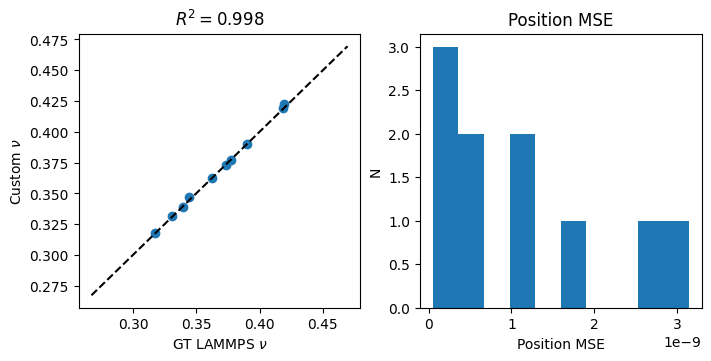

In [36]:
fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(7, 3.5))

line = (min(results["gt_box_p"])-0.05, max(results["gt_box_p"])+0.05)
ax[0].plot(line, line, linestyle="--", color='black')
ax[0].scatter(results["gt_box_p"], results["custom_box_p"])
ax[0].set_xlabel("GT LAMMPS $\\nu$")
ax[0].set_ylabel("Custom $\\nu$")
ax[0].set_title(f"$R^2={r2_score(results['gt_box_p'], results['custom_box_p']):.3f}$")

ax[1].hist(results["position_mse"])
ax[1].set_xlabel("Position MSE")
ax[1].set_ylabel("N")
ax[1].set_title("Position MSE")

plt.show()

#### Check diffirentiability

In [25]:
sim = random.sample(test_data, k=1)[0]
data_step0 = sim[0].to(device)

data_step0 = to_f64(data_step0)
data_step0.x.requires_grad_(True)

simulator = DifferentiableCompression64(
    num_particles=sim[0].num_nodes,
    mass=1.0e6,
    dt=0.01,
    damp=10,
    ptemp=1e-4,
    pdamp=1000,
    target_p=0.0,
    srate=1e-5,
    temp_langevin=1e-7,
    lj_params=LJInteractionParams(epsilon=0.01, sigma=1.0, cutoff=1.122) if dataset_type is DatasetType.LJNoisy else None,
    factor_two=True
)

traj, cond = simulator.run_simulator(data_step0, 1000, debug=False, r0=data_step0.edge_attr[:, -2], device=device)
traj = [to_f32(g) for g in traj]
loss = torch.nn.functional.mse_loss(sim[50].x, data_step0.x)

try:
    grad_check = torch.autograd.grad(loss, data_step0.x, retain_graph=True)
    print(f"Mean grad: {grad_check[0].abs().mean().item()}")
except RuntimeError as e:
    print(f"error: {e}")


Mean grad: 1.8925295080407523e-05


### Stress-strain

In [ ]:
def fit_line(function: Tensor | pd.Series | Iterable, fit_to_steps: int):

    if isinstance(function, Tensor):
        y = function[:fit_to_steps].numpy()
    elif isinstance(function, pd.Series):
        y = function[:fit_to_steps].to_numpy()
    else:
        y = function[:fit_to_steps]

    x = np.array(range(fit_to_steps))

    a, b = np.polyfit(x, y, deg=1)
    line_y = np.array([a * x + b for x in range(len(function))])
    return line_y


def get_affine_trajectory(traj: list[Data]) -> list[Data]:
    if not traj:
        return []

    a_traj = deepcopy(traj)

    init_pos = traj[0].cpu().x
    init_box = traj[0].box_tensor
    center_init = torch.mean(init_pos, dim=0)

    rel_init = init_pos - center_init

    for t in range(len(traj)):
        current_pos = traj[t].cpu().x
        current_box = traj[t].box_tensor

        lambda_x = (current_box[0] / init_box[0]).item()
        lambda_y = (current_box[1] / init_box[1]).item()

        center_current = torch.mean(current_pos, dim=0)

        affine_rel = torch.zeros_like(rel_init)
        affine_rel[:, 0] = rel_init[:, 0] * lambda_x
        affine_rel[:, 1] = rel_init[:, 1] * lambda_y

        affine_pos = affine_rel + center_current
        
        # Update
        device = traj[t].x.device
        a_traj[t].x = affine_pos.to(device)
        
 
    return a_traj


def get_non_affine_trajectory(traj: list[Data]) -> list[Data]:

    na_traj = deepcopy(traj)

    init_pos = traj[0].cpu().x
    init_box = traj[0].box_tensor
    center_init = torch.mean(init_pos, dim=0)

    for t in range(len(traj)):
        current_pos = traj[t].cpu().x
        current_box = traj[t].box_tensor
        
        # Change factor relative to t=0
        lambda_x = (current_box[0] / init_box[0]).item()
        lambda_y = (current_box[1] / init_box[1]).item()
        
        # Current center coords
        center_current = torch.mean(current_pos, dim=0)
        rel_current = current_pos - center_current
        
        # Affine subtraction
        non_affine_rel = torch.zeros_like(rel_current)
        non_affine_rel[:, 0] = rel_current[:, 0] / lambda_x
        non_affine_rel[:, 1] = rel_current[:, 1] / lambda_y

        non_affine_pos = non_affine_rel + center_init
        
        # Update
        device = traj[t].x.device
        na_traj[t].x = non_affine_pos.to(device)

        if hasattr(na_traj[t], 'box_tensor') and na_traj[t].box_tensor is not None:
            na_traj[t].box_tensor = init_box.clone().to(device)
            
    return na_traj


def plot_displacement_components(
    traj: list[Data], 
    t: int, 
    scale_vectors: float = 1.0, 
    show_edges: bool = True
):
    na_traj = get_non_affine_trajectory(traj)
    a_traj = get_affine_trajectory(traj)
    
    init_data = traj[0].cpu()
    init_pos = init_data.x.numpy()
    init_box = init_data.box_tensor.numpy()
    
    edges = init_data.edge_index.numpy()

    na_pos_t = na_traj[t].cpu().x.numpy()
    a_pos_t = a_traj[t].cpu().x.numpy()

    na_disp = na_pos_t - init_pos
    a_disp = a_pos_t - init_pos

    # Setup plotting logic
    _fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    
    def plot_field(ax, coords, disp, edges, box_dims, title, vector_color):
        
        # Plot Edges with Minimum Image Convention (MIC)
        if show_edges and edges is not None:
            start_nodes = coords[edges[0]]
            raw_end_nodes = coords[edges[1]]
            
            # Calculate raw edge vectors
            edge_dx = raw_end_nodes[:, 0] - start_nodes[:, 0]
            edge_dy = raw_end_nodes[:, 1] - start_nodes[:, 1]
            
            # Apply MIC: wrap distances greater than half the box length
            edge_dx -= box_dims[0] * np.round(edge_dx / box_dims[0])
            edge_dy -= box_dims[1] * np.round(edge_dy / box_dims[1])
            
            # Reconstruct corrected end nodes (pointing out into the virtual cell)
            corrected_end_nodes = np.column_stack((
                start_nodes[:, 0] + edge_dx,
                start_nodes[:, 1] + edge_dy
            ))
            
            segments = np.stack([start_nodes, corrected_end_nodes], axis=1)
            lc = LineCollection(segments, colors='black', linewidths=0.5, alpha=0.3, zorder=1)
            ax.add_collection(lc)

        ax.scatter(coords[:, 0], coords[:, 1], c='lightgray', s=15, alpha=0.6, zorder=2)

        ax.quiver(
            coords[:, 0], coords[:, 1], 
            disp[:, 0], disp[:, 1], 
            angles='xy', scale_units='xy', scale=1.0 / scale_vectors, 
            color=vector_color, width=0.003, alpha=0.8, headwidth=4, zorder=3
        )

        ax.set_aspect('equal')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(True, alpha=0.2)

    plot_field(
        ax1, init_pos, a_disp, edges, init_box, 
        f"Affine Displacements ($t=0 \\rightarrow {t}$)\nScale: {scale_vectors}x", 
        vector_color='blue'
    )
    
    plot_field(
        ax2, init_pos, na_disp, edges, init_box, 
        f"Non-Affine Displacements ($t=0 \\rightarrow {t}$)\nScale: {scale_vectors}x", 
        vector_color='red'
    )

    plt.tight_layout()
    plt.show()


In [ ]:
random_idx = random.sample(range(len(results["stress"])), k=1)[0]
sim_stress = results["stress"][random_idx]
sim_strain = results["strain"][random_idx]
print(f"Strain: {sim_strain:.6f}")
stress_xx = sim_stress[:, 0]
stress_yy = sim_stress[:, 1]

strain = torch.linspace(0, sim_strain, len(stress_xx)) * 100

fig, ax = plt.subplots(1, 1, layout="tight", figsize=(6, 6))

fit_to_steps = 2
y_line = fit_line(stress_xx, fit_to_steps)

ax.plot(strain, y_line, linestyle="--", color="black")
ax.plot(strain, stress_xx)
ax.set_ylabel(r"$\sigma_{xx}$")
ax.set_xlabel(r"$\epsilon$, %")
plt.show()


### Minimization testing

For data containing LJ interactions

#### Noise stiffness

In [ ]:
def get_reverse_edge_indices(edge_index: Tensor) -> Tensor:
    """
    Returns a tensor 'rev_idx' such that edge_index[:, i] is the reverse of edge_index[:, rev_idx[i]].
    Assumes every edge has a reverse.
    """
    # Convert (u, v) to a single unique number to find matches easily
    # We assume node indices fit in 32/64 bit integers.
    # Max node index * multiplier + min node index approach.

    src, dst = edge_index

    # 1. Create a hash/id for every edge
    # This ID is unique for every directed edge
    # Using complex numbers is a quick hack to keep pairs together: u + iv
    # But simple Cantor pairing or large integer multiplication is safer for tensors
    scaling = src.max() + 1
    edge_ids = src * scaling + dst
    reverse_edge_ids = dst * scaling + src

    # 2. Find where the reverse ID exists in the original list
    # Torch's sort is efficient for this
    perm = torch.argsort(edge_ids)
    sorted_ids = edge_ids[perm]

    # Find indices of reverse edges in the sorted array
    sorted_rev_indices = torch.searchsorted(sorted_ids, reverse_edge_ids)

    # Map back to original indices
    rev_idx = perm[sorted_rev_indices]

    return rev_idx

# Pick random graph
random_idx = random.randint(0, len(data['train'])-1)
random_sim = data['train'][random_idx]
random_graph = random_sim[0]

# Add perturbation
is_harmonic = random_graph.edge_attr[:, 0].bool()
stiff_idx = 5
r0_idx = 6

initial_stiff = random_graph.edge_attr[is_harmonic, stiff_idx].clone()
harm_edge_index = random_graph.edge_index[:, is_harmonic]
rev_idx = get_reverse_edge_indices(harm_edge_index)

stiffness_adjustment = torch.randn_like(initial_stiff) * 0.02
symmetric_adjustment = (stiffness_adjustment + stiffness_adjustment[rev_idx]) / 2.0

max_mult = 5.0
min_mult = 1e-6
log_max = torch.log(torch.tensor(max_mult))   
log_min = torch.log(torch.tensor(min_mult))

scale = torch.where(
    symmetric_adjustment >= 0,
    log_max,
    -log_min
)

multiplier = torch.exp(scale * torch.tanh(symmetric_adjustment))
new_stiff = initial_stiff * multiplier

noised_graph = deepcopy(random_graph)
noised_graph.edge_attr[is_harmonic, stiff_idx] = new_stiff

# Plot old stiff vs. new stiff
shared_bins = np.linspace(0.3, 2.1, 41)
plt.hist(initial_stiff, edgecolor='black', alpha=0.7, bins=shared_bins, label='Original')
plt.hist(new_stiff,     edgecolor='black', alpha=0.7, bins=shared_bins, label='Noised')
plt.legend()
plt.show()

#### Energy minimization

In [ ]:
simulator = DifferentiableCompression64(
    num_particles=random_graph.num_nodes,
    lj_params=LJInteractionParams(0.01, 1.0, 1.122),
    temp_langevin=0.0
)
old_r0 = noised_graph.edge_attr[is_harmonic, r0_idx]
minimized_graph = simulator.minimize(noised_graph, old_r0, max_iter=1000, ftol=1e-6, stress_tol=1e-7, relax_box=True, target_stress=0.0, box_lr=1e-2)

#region output
with torch.no_grad():
    gt_stress, gt_pressure = compute_stress_pressure(
        pos=random_graph.x,
        edge_index=random_graph.edge_index,
        edge_attr=random_graph.edge_attr,
        box_tensor=random_graph.box_tensor,
        lj_cutoff=1.122,
        r0_override=old_r0,
    )

    noised_stress, noised_pressure = compute_stress_pressure(
        pos=noised_graph.x,
        edge_index=noised_graph.edge_index,
        edge_attr=noised_graph.edge_attr,
        box_tensor=noised_graph.box_tensor,
        lj_cutoff=1.122,
        r0_override=old_r0,
    )

    minimized_stress, minimized_pressure = compute_stress_pressure(
        pos=minimized_graph.x,
        edge_index=minimized_graph.edge_index,
        edge_attr=minimized_graph.edge_attr,
        box_tensor=minimized_graph.box_tensor,
        lj_cutoff=1.122,
        r0_override=old_r0,
    )

    print(f"Stress XX original:  {gt_stress[0].item():.8f}")
    print(f"Stress XX noised:    {noised_stress[0].item():.8f}")
    print(f"Stress XX minimized: {minimized_stress[0].item():.8f}\n")

    print(f"Stress YY original:  {gt_stress[1].item():.8f}")
    print(f"Stress YY noised:    {noised_stress[1].item():.8f}")
    print(f"Stress YY minimized: {minimized_stress[1].item():.8f}\n")


    default_mse = (random_graph.x - noised_graph.x).pow(2).mean()
    print(f"Position MSE before optimization: {default_mse:.4e}")
    noised_mse = (random_graph.x - minimized_graph.x).pow(2).mean()
    print(f"Position MSE after optimization: {noised_mse:.4e}\n")

    # potential_energy_original = compute_potential_energy(random_graph, r0=random_graph.edge_attr[:, 6], lj_cutoff=1.122)
    # potential_energy_noised = compute_potential_energy(noised_graph, r0=noised_graph.edge_attr[:, 6], lj_cutoff=1.122)
    # potential_energy_minimized = compute_potential_energy(minimized_graph, r0=minimized_graph.edge_attr[:, 6], lj_cutoff=1.122)

    # print(f"E_pot original:  {potential_energy_original:.4e}")
    # print(f"E_pot noised:    {potential_energy_noised:.4e}")
    # print(f"E_pot minimized: {potential_energy_minimized:.4e}\n")

    forces_original =  compute_per_particle_forces(random_graph,    r0=random_graph.edge_attr[:, 6],    cutoff=1.122)
    forces_noised =    compute_per_particle_forces(noised_graph,    r0=noised_graph.edge_attr[:, 6],    cutoff=1.122)
    forces_minimized = compute_per_particle_forces(minimized_graph, r0=minimized_graph.edge_attr[:, 6], cutoff=1.122)

    # print(f"F_total original:  {forces_original.sum():.4e}")
    # print(f"F_total noised:    {forces_noised.sum():.4e}")
    # print(f"F_total minimized: {forces_minimized.sum():.4e}\n")

    print(f"Max F original:  {forces_original.abs().max():.4e}")
    print(f"Max F noised:    {forces_noised.abs().max():.4e}")
    print(f"Max F minimized: {forces_minimized.abs().max():.4e}\n")

    print(f"Old box: {random_graph.box_tensor[0].item():6f}, {random_graph.box_tensor[1].item():6f}")
    print(f"Old box: {minimized_graph.box_tensor[0].item():6f}, {minimized_graph.box_tensor[1].item():6f}")

visualize_graphs(random_graph, minimized_graph, node_size=10)
#endregion

In [ ]:
def detach_to_cpu(x):
    if torch.is_tensor(x):
        return x.detach().cpu()
    return x

with torch.no_grad():
    random_traj, _ = simulator.run_simulator(
        random_graph.apply(detach_to_cpu),
        2_000,
        random_graph.edge_attr[:, 6].cpu(),
        False,
        "cpu",
    )
    noised_traj, _ = simulator.run_simulator(
        noised_graph.apply(detach_to_cpu),
        2_000,
        noised_graph.edge_attr[:, 6].cpu(),
        False,
        "cpu",
    )
    minimized_traj, _ = simulator.run_simulator(
        minimized_graph.apply(detach_to_cpu),
        2_000,
        minimized_graph.edge_attr[:, 6].cpu(),
        False,
        "cpu",
    )

In [ ]:
random_stress_curve = compute_stress_curve(random_traj, 1.122, 100, "cpu")
noised_stress_curve = compute_stress_curve(noised_traj, 1.122, 100, "cpu")
minimized_stress_curve = compute_stress_curve(minimized_traj, 1.122, 100, "cpu")

plt.plot(random_stress_curve[:, 0].detach().cpu(), label='Original')
# plt.plot(noised_stress_curve[:, 0].detach().cpu(), label='Noised')
plt.plot(minimized_stress_curve[:, 0].detach().cpu(), label='Minimized')
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Step")
plt.legend()
plt.show()


### Compare runtime with LJ interactions

#### Load data with and without LJ interactions

In [ ]:
poisson_buckets = [
    {"min": -1.0, "max": 1.0, "count": 200}, # Full range
]

#region Default data

dataset_type = DatasetType.NodeOptimized

train_files, val_files, test_files = load_and_split_dataset(
    registry_path="./data/new_node_optimized/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.9, 0.05, 0.05),
    seed=42
)

# Load actual data
default_data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 300
print(f"Loading data with max simulation length of {max_sim_len}...")
for key in default_data:
    if key == 'train':
        default_data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        default_data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        default_data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in default_data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, lj_params=None, calc_angles=False)
        prepared.append(prepared_sim)
    default_data[data_type] = prepared

#endregion

#region LJ data

dataset_type = DatasetType.LJNoisy

train_files, val_files, test_files = load_and_split_dataset(
    registry_path="./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.9, 0.05, 0.05),
    seed=42
)

# Load actual data
lj_data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 300
print(f"Loading data with max simulation length of {max_sim_len}...")
for key in lj_data:
    if key == 'train':
        lj_data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        lj_data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        lj_data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
default_params = LJInteractionParams(epsilon=0.01, sigma=1.0, cutoff=1.122)
for data_type, sims in lj_data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, default_params, calc_angles=False)
        prepared.append(prepared_sim)
    lj_data[data_type] = prepared

#endregion


In [ ]:
default_sizes = [sim[0].num_nodes for sim in default_data['train'] if sim[0].num_nodes <= 100][:10]
lj_sizes = [sim[0].num_nodes for sim in lj_data['train'] if sim[0].num_nodes <= 100][:10]

default_sims = [sim for sim in default_data['train'] if sim[0].num_nodes <= 100][:10]
lj_sims = [sim for sim in lj_data['train'] if sim[0].num_nodes <= 100][:10]

data_min = min(min(default_sizes), max(lj_sizes))
data_max = max(min(default_sizes), max(lj_sizes))
shared_bins = np.linspace(data_min, data_max, 21)

plt.hist(default_sizes, bins=shared_bins, edgecolor="black", alpha=0.6, label=f"Default: {len(default_sims)}")
plt.hist(lj_sizes,      bins=shared_bins, edgecolor="black", alpha=0.6, label=f"LJ: {len(lj_sims)}")
plt.xlabel("Num nodes")
plt.ylabel("$N$")
plt.legend()
plt.show()

In [ ]:
print(default_data['train'][0][0].edge_attr.shape[1])
print(lj_data['train'][0][0].edge_attr.shape[1])

In [ ]:
import torch._dynamo

steps = 3_000
device = "cpu"

def run_torch_simulator(steps: int, input_sims: list[list[Data]], lj_params: LJInteractionParams | None, device: str = "cpu") -> dict[str, list]:
    results = {
        "time_total_wall": 0.0,
        "time_simulation_only": 0.0,
        "position_mse": [],
        "gt_box_change": [],
        "gt_box_p": [],
        "custom_box_p": [],
        "custom_box_change": [],
        "stress": [],
        "strain": [],
    }

    # Warmup phase (Eliminates torch.compile overhead)
    print("Warming up compiled simulator...")
    sim0 = input_sims[0]
    data_step0 = sim0[0].to(device)
    
    # Determine r0
    if data_step0.edge_attr.shape[1] == 4:
        r0 = data_step0.edge_attr[:, -2]
    elif data_step0.edge_attr.shape[1] == 7:
        r0 = data_step0.edge_attr[data_step0.edge_attr[:, 0] == 1][:, 4]
    
    dummy_simulator = DifferentiableCompression64(num_particles=sim0[0].num_nodes, lj_params=lj_params)

    # Run a short rollout to trigger the compiler
    _ = dummy_simulator.run_simulator(
        initial_data=to_f64(data_step0), steps=2, r0=r0, debug=False, device=device
    )

    # Benchmark phase
    t_start_wall = time.time()
    total_sim_time = 0.0

    for sim in tqdm(input_sims):
        simulator = DifferentiableCompression64(num_particles=sim[0].num_nodes, lj_params=lj_params)

        strain = (sim[0].box.x - sim[-1].box.x) / sim[0].box.x
        assumed_rollout_length = int(strain / 1e-5 / 0.01)
        dump_period = int(assumed_rollout_length / len(sim)) + 1
        data_step0 = sim[0].to(device)
    
        if data_step0.edge_attr.shape[1] == 4:
            r0 = data_step0.edge_attr[:, -2]
        elif data_step0.edge_attr.shape[1] == 7:
            r0 = data_step0.edge_attr[data_step0.edge_attr[:, 0] == 1][:, 4]
        else:
             raise ValueError(f"Unexpected edge_attr dimension: {data_step0.edge_attr.shape[1]}")

        t0_sim = time.time()

        simulator_rollout, _conditions = simulator.run_simulator(
            initial_data=to_f64(data_step0), steps=steps, r0=r0, debug=False, device=device,
        )

        total_sim_time += (time.time() - t0_sim)

        # Coarse grain to match GT Lammps 
        simulator_rollout = [step for i, step in enumerate(simulator_rollout) if i % dump_period == 0]
        target_idx = len(simulator_rollout) - 1

        # Collect metrics (Untimed by the sim timer, but included in wall time)
        results["gt_box_change"].append([graph.box_tensor.cpu().detach() for graph in sim[:target_idx]])
        results["custom_box_change"].append([graph.box_tensor.cpu().detach() for graph in simulator_rollout[:target_idx]])
        
        mse = torch.nn.functional.mse_loss(simulator_rollout[-1].x, sim[target_idx].x)
        results["position_mse"].append(mse.item())
        results["gt_box_p"].append(calc_p_ratio_box_tensor(sim, target_idx).item())
        results["custom_box_p"].append(calc_p_ratio_box_tensor(simulator_rollout, target_idx).item())
        
        stress_curve = compute_stress_curve(simulator_rollout, lj_cutoff=1.122, sample_stride=1)
        results["stress"].append(stress_curve.detach())
        
        final_strain = (sim[0].box_tensor[0] - sim[target_idx].box_tensor[0]) / sim[0].box_tensor[0]
        results["strain"].append(final_strain.item())
    
    results['time_total_wall'] = time.time() - t_start_wall
    results['time_simulation_only'] = total_sim_time

    return results

# Flush the cache
print("Flushing torch.compile cache...")
torch._dynamo.reset()

# Benchmark default dataset
print("Benchmarking Default Sims...")
default_results = run_torch_simulator(steps, default_sims, None, device)

# Flush the cache
print("Flushing torch.compile cache...")
torch._dynamo.reset()

# Benchmark the LJ dataset
print("Benchmarking LJ Sims...")
lj_results = run_torch_simulator(steps, lj_sims, default_params, device)


In [ ]:
print(f"Total wall time: {default_results['time_total_wall']:.2f} s.")
print(f"Total wall time: {lj_results['time_total_wall']:.2f} s.")

print(f"Sim only time: {default_results['time_simulation_only']:.2f} s.")
print(f"Sim only time: {lj_results['time_simulation_only']:.2f} s.")